## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [3]:
# Path to load the data

# Amélie
# link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
link = r"E:\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [4]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            print(list_of_rewards)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

Episode:  0
Time | ep_step:  0 0


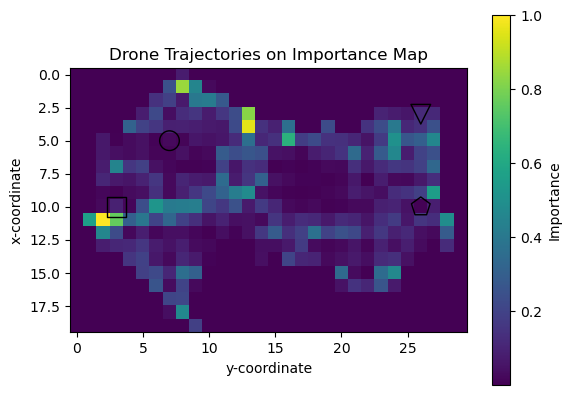

[3.332693861797452, -3.5151817383447224, 8.499181708320975, -0.9187176283448933]
Time | ep_step:  1 1
[-2.5311876945197587, -0.8147801624822648, -9.316959410905838, 0.875622622668743]
Time | ep_step:  2 2
[0.017963535711169043, 0.6025391473040855, 0.4895467398857828, -1.5358687061816456]
Time | ep_step:  3 3
[6.01875305213034, 4.160227544605732, 1.1285152075981841, 0.9083778006024662]
Time | ep_step:  4 4
[4.57070755008608, 7.203920275311972, 7.397235954722192, -0.5762094020843506]
-----------
Episode:  1
Time | ep_step:  5 0
[-4.866943072527647, 0.34070362638258855, 0.020123583823442592, 1.69595872326754]
Time | ep_step:  6 1
[8.131019862368703, -7.78446254485631, -3.3107161713933726, 6.4304544034414]
Time | ep_step:  7 2
[5.7565536024048924, 1.6649574710132564, 0.15137315107343174, -7.72237020080909]
Time | ep_step:  8 3
[4.884835849363754, 3.9371128427386797, -0.13444246625361367, 7.105578239816243]
Time | ep_step:  9 4
[0.8573797566274377, -0.306259112499976, 7.339356555119156, 1.6

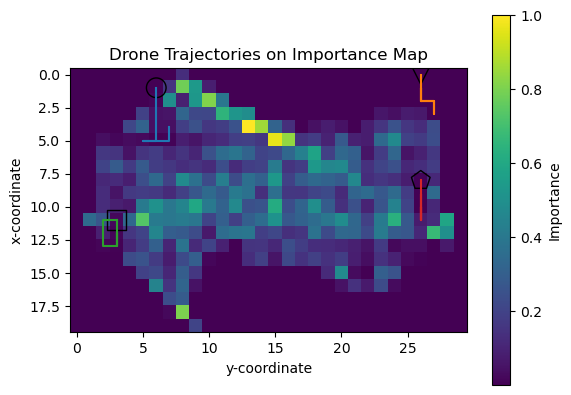

[-2.4330097956794527, 4.625000749999998, 3.9520525105297555, 5.551276383921504]
Time | ep_step:  11 1
[7.249833938818028, 4.25, 6.787962945178153, 4.454523459076881]
Time | ep_step:  12 2
[8.929136737879732, -0.7500099999999743, 4.0926043735817075, 5.711907237768175]
Time | ep_step:  13 3
[0.05086296911859467, 9.250009999999975, 4.895195352844894, 3.508451472967863]
Time | ep_step:  14 4
[0.05042558561587307, -9.125019124999952, 1.2384343277663001, -7.711595072369889]
-----------
Episode:  3
Time | ep_step:  15 0
[-0.4682721284893776, 9.000017374999958, 2.4526152698492756, -0.9241564672230766]
Time | ep_step:  16 1
[1.7454192657491008, -8.875017837499957, 5.537225356474551, 4.21140892629328]
Time | ep_step:  17 2
[0.4218010498595204, 8.750017662499957, 1.9926781548145134, -3.968134911249974]
Time | ep_step:  18 3
[3.39529258144853, -8.625017258749958, 4.25, 1.025000074999999]
Time | ep_step:  19 4
[4.25, 9.862517241249956, 4.25, -0.24812747124999282]
-----------
Episode:  4
Time | ep_s

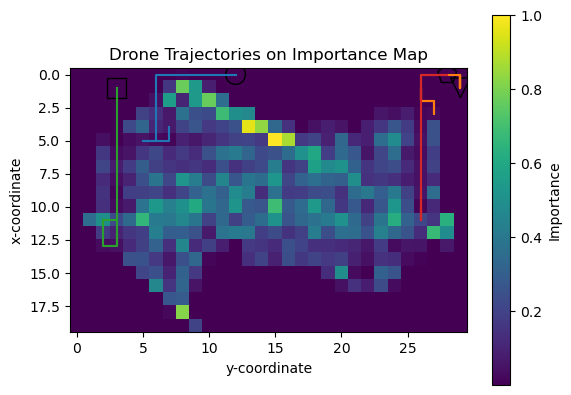

[4.25, -9.737519500962451, -0.7500099999999743, -5.248135272212474]
Time | ep_step:  21 1
[4.25, 9.612519449037451, 4.25, 9.612519449037451]
Time | ep_step:  22 2
[4.25, -9.487518975259576, 1.2499940000000163, -9.487518975259576]
Time | ep_step:  23 3
[4.25, 9.362518974740327, -1.5000060999999825, 9.362518974740327]
Time | ep_step:  24 4
[4.25, -9.23751847500255, 4.895502253388449, -9.23751847500255]
-----------
Episode:  5
Time | ep_step:  25 0
[4.25, 9.112518474997355, 7.026131052484541, 9.112518474997355]
Time | ep_step:  26 1
[4.25, -8.987517974999982, -1.1867479430434225, -8.987517974999982]
Time | ep_step:  27 2
[4.25, 8.86251797499993, -3.340355490656247, 8.86251797499993]
Time | ep_step:  28 3
[4.25, -8.737517474999956, 0.4309241278266651, -8.737517474999956]
Time | ep_step:  29 4
[4.25, 8.612517474999956, 1.2124999999999997, 8.612517474999956]
-----------
Episode:  6
Time | ep_step:  30 0


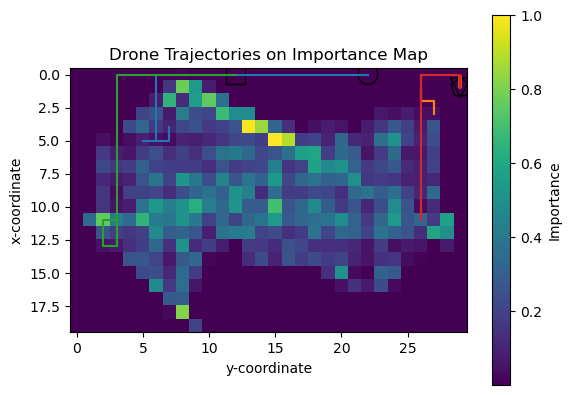

[4.25, -8.487516974999957, 1.2124999999999997, -8.487516974999957]
Time | ep_step:  31 1
[4.25, 8.362516974999956, 1.2124999999999997, 8.362516974999956]
Time | ep_step:  32 2
[1.262494025000016, -8.237516474999957, 1.2124999999999997, -8.237516474999957]
Time | ep_step:  33 3
[-1.2625031499999928, 9.82376649772723, -1.2125024424999946, 6.999884587348456]
Time | ep_step:  34 4
[1.262501899999996, -9.698769397499952, 1.2125024074999937, -6.999887487121176]
-----------
Episode:  7
Time | ep_step:  35 0
[-0.5750047224999869, 9.57376937499995, 1.5962503174999991, 9.57376937499995]
Time | ep_step:  36 1
[2.638751954999994, -9.448768897499951, 1.5962503174999991, -9.448768897499951]
Time | ep_step:  37 2
[-0.34998856596211825, 9.944893897274952, 1.4375000000000004, 9.944893897274952]
Time | ep_step:  38 3
[-5.349996689618913, -9.819894642022675, 1.4375000000000004, -9.819894642022675]
Time | ep_step:  39 4
[5.599998238121184, 9.9820071397477, 1.6249999958972745e-07, 9.9820071397477]
--------

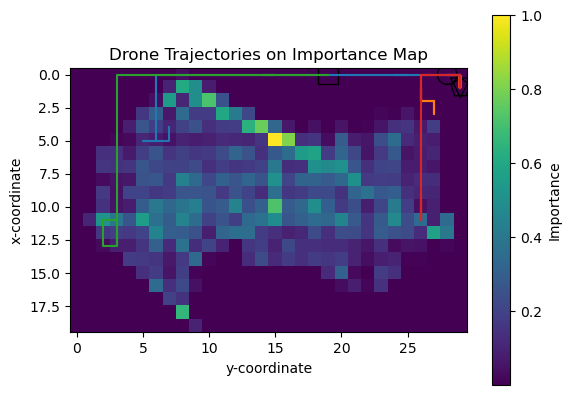

[-5.599998312350708, -9.857007213977223, 1.437499775000001, -9.857007213977223]
Time | ep_step:  41 1
[9.7320072117022, 9.7320072117022, 1.7312503625, 9.7320072117022]
Time | ep_step:  42 2
[-9.607006713974954, -9.607006713974954, 1.5500000000000003, -9.607006713974954]
Time | ep_step:  43 3
[9.482006713972678, 9.482006713972678, 0.8624986250000028, 9.482006713972678]
Time | ep_step:  44 4
[-9.357006213974955, -9.357006213974955, 0.8624998624999997, -9.357006213974955]
-----------
Episode:  9
Time | ep_step:  45 0
[9.23200621397495, 9.23200621397495, 1.0262501899999992, 9.23200621397495]
Time | ep_step:  46 1
[-9.107005713974953, -9.107005713974953, -0.05500226724999266, -9.107005713974953]
Time | ep_step:  47 2
[8.982005713974953, 8.982005713974953, 1.6617639162749933, 8.982005713974953]
Time | ep_step:  48 3
[-9.898218546397452, -9.898218546397452, -0.39750200229711924, -9.898218546397452]
Time | ep_step:  49 4
[9.773218296172226, 9.773218296172226, -5.397510170099825, 9.773218296172

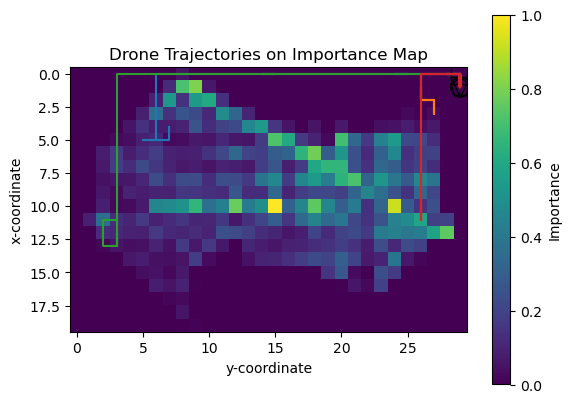

[-9.648218046647676, -9.648218046647676, 9.648218296147224, -9.648218046647676]
Time | ep_step:  51 1
[9.523218046372431, 9.523218046372431, -9.523217796422475, 9.523218046372431]
Time | ep_step:  52 2
[-9.398217546397477, -9.398217546397477, 9.398217796397427, -9.398217546397477]
Time | ep_step:  53 3
[9.27321754639745, 9.27321754639745, -9.273217296397455, 9.27321754639745]
Time | ep_step:  54 4
[-9.148217046397454, -9.148217046397454, 9.148217296397453, -9.148217046397454]
-----------
Episode:  11
Time | ep_step:  55 0
[9.023217046397454, 9.023217046397454, -9.023216796397454, 9.023217046397454]
Time | ep_step:  56 1
[-8.898216546397455, -8.898216546397455, 8.898216796397454, -8.898216546397455]
Time | ep_step:  57 2
[8.773216546397455, 8.773216546397455, -8.773216296397456, 8.773216546397455]
Time | ep_step:  58 3
[-8.648216046397456, -8.648216046397456, 8.648216296397456, -8.648216046397456]
Time | ep_step:  59 4
[8.523216046397458, 8.523216046397458, -8.523215796397457, 8.5232160

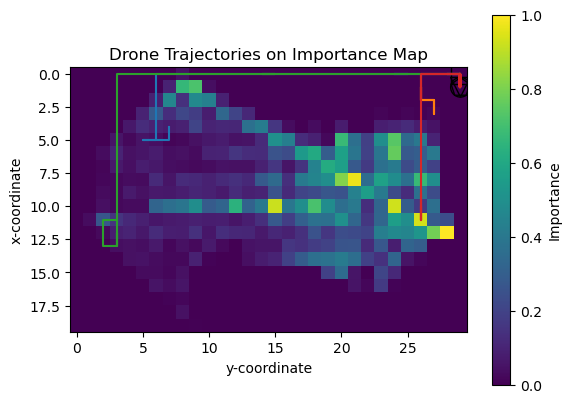

[-9.649999975636094e-06, 5.0226805203602485, 1.8226262370077475, 5.0226805203602485]
Time | ep_step:  61 1
[-5.173533293296372, -8.226141244656606, -1.947628935156638, -8.226141244656606]
Time | ep_step:  62 2
[5.017362124671372, 7.989765909591715, -2.2990824166953748e-07, -6.99082420734981e-08]
Time | ep_step:  63 3
[-5.142495289705439, -7.853639230013284, 5.142495493944614, -2.288879078263315]
Time | ep_step:  64 4
[5.142495764480462, -2.540116830227465, -5.142495269435415, 5.142495764480462]
-----------
Episode:  13
Time | ep_step:  65 0
[-5.1424952669827135, 5.142495766933163, 5.142495766933163, -5.1424952669827135]
Time | ep_step:  66 1
[5.14249576695769, -5.142495266958187, -5.142495266958187, 5.14249576695769]
Time | ep_step:  67 2
[-5.142495266957941, 5.142495766957936, 5.142495766957936, -5.142495266957941]
Time | ep_step:  68 3
[5.142495766957937, -5.14249526695794, -5.14249526695794, 5.142495766957937]
Time | ep_step:  69 4
[-5.14249526695794, 5.142495766957937, 5.1424957669

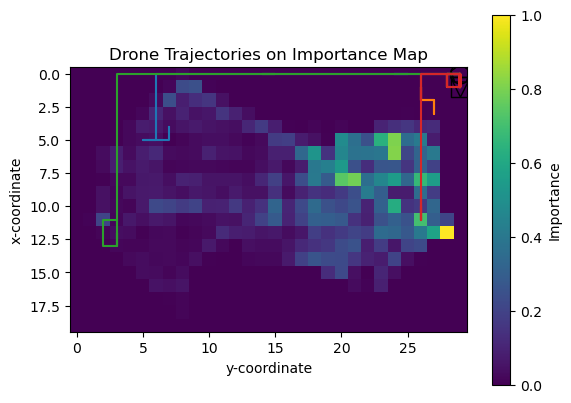

[5.142495766957937, -5.14249526695794, -5.14249526695794, 5.142495766957937]
Time | ep_step:  71 1
[-1.5814999960070964e-06, 3.2493801737234063, 5.0142572266691925, 4.9625098203041835]
Time | ep_step:  72 2
[-5.218010038069554, -3.3743816560026434, -5.218010038069554, -6.852263362002622]
Time | ep_step:  73 3
[5.021810015581668, 3.419056824849718, 5.021810015581668, 6.4785130330997]
Time | ep_step:  74 4
[-5.1475975436979216, -3.544056839674761, -5.1475975436979216, -6.603512583574745]
-----------
Episode:  15
Time | ep_step:  75 0
[5.1475977912254445, 5.1475977912254445, 5.1475977912254445, -3.920180840572709]
Time | ep_step:  76 1
[-5.14759754395042, -5.14759754395042, -5.14759754395042, 5.147598043445919]
Time | ep_step:  77 2
[5.147598043672923, 5.147598043672923, 5.147598043672923, -5.147597543723419]
Time | ep_step:  78 3
[-5.147597543698196, -5.147597543698196, -5.147597543698196, 5.147598043698144]
Time | ep_step:  79 4
[-9.001575026605405e-07, 4.920308940316225, 5.722676795027

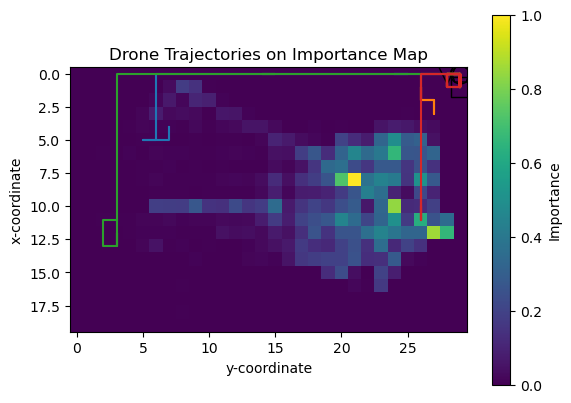

[5.72267794518479, -5.170309590598715, -5.722677445184791, 5.72267794518479]
Time | ep_step:  81 1
[-5.72267744518479, 5.72267794518479, 5.72267794518479, -5.72267744518479]
Time | ep_step:  82 2
[5.72267794518479, -5.72267744518479, -5.72267744518479, 5.72267794518479]
Time | ep_step:  83 3
[-5.72267744518479, 5.72267794518479, 5.72267794518479, -5.72267744518479]
Time | ep_step:  84 4
[5.722677945184791, -5.722677445184791, -5.722677445184791, 5.722677945184791]
-----------
Episode:  17
Time | ep_step:  85 0
[-5.72267744518479, 5.72267794518479, 5.72267794518479, -5.72267744518479]
Time | ep_step:  86 1
[5.72267794518479, -5.72267744518479, -5.72267744518479, 5.72267794518479]
Time | ep_step:  87 2
[-5.722677445184791, 5.722677945184791, 5.722677945184791, -5.722677445184791]
Time | ep_step:  88 3
[5.722677945184791, -5.722677445184791, -5.722677445184791, 5.722677945184791]
Time | ep_step:  89 4
[-5.722677445184791, 5.722677945184791, 5.722677945184791, -5.722677445184791]
---------

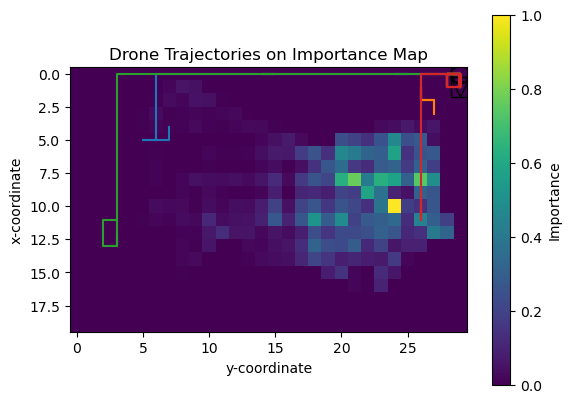

[5.72267794518479, -5.72267744518479, -5.72267744518479, 5.72267794518479]
Time | ep_step:  91 1
[-5.722677445184791, 5.722677945184791, 5.722677945184791, -5.722677445184791]
Time | ep_step:  92 2
[5.722677945184791, -5.722677445184791, -5.722677445184791, 5.722677945184791]
Time | ep_step:  93 3
[-5.722677445184791, 5.722677945184791, 5.722677945184791, -5.722677445184791]
Time | ep_step:  94 4
[5.72267794518479, -5.72267744518479, -5.72267744518479, 5.72267794518479]
-----------
Episode:  19
Time | ep_step:  95 0
[5.192506744201503, -3.215015742148691e-06, 5.139774564519232, -5.072281285333445]
Time | ep_step:  96 1
[-5.001260346501548, 5.370527559531748, -5.3885283735365475, 5.370527559531748]
Time | ep_step:  97 2
[-5.514653029284973, -5.370527905783321, 5.37052840128332, -5.370527905783321]
Time | ep_step:  98 3
[5.370528403283571, 5.370528403283571, -5.370527903783072, 5.370528403283571]
Time | ep_step:  99 4
[-5.370527903533548, -5.370527903533548, 5.370528403533096, -5.3705279

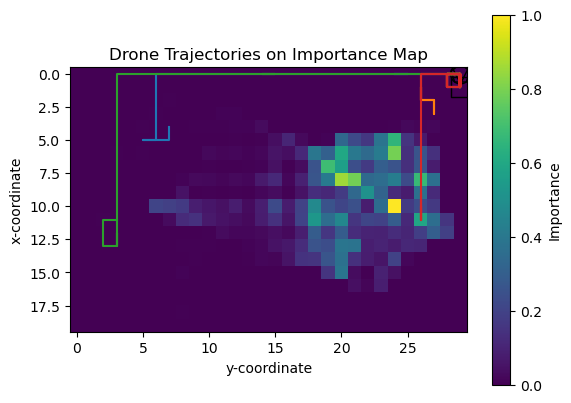

[5.370528403533296, 5.370528403533296, -5.370527903533347, 5.370528403533296]
Time | ep_step:  101 1
[5.051933600860494, 5.051933600860494, 4.883906758132669, -4.956984091934806]
Time | ep_step:  102 2
[-5.012510102812742, -5.012510102812742, -5.121407770605591, 5.133388363857806]
Time | ep_step:  103 3
[-5.2576576902952, -5.2576576902952, 5.133388919169323, -5.1333884641693235]
Time | ep_step:  104 4
[5.133388939171821, 5.133388939171821, -5.1333884441668225, 5.133388939171821]
-----------
Episode:  21
Time | ep_step:  105 0
[-5.133388441671572, -5.133388441671572, 5.133388941667071, -5.133388441671572]
Time | ep_step:  106 1
[5.133388941669073, 5.133388941669073, -5.133388441669573, 5.133388941669073]
Time | ep_step:  107 2
[-5.133388441669323, -5.133388441669323, 5.133388941669321, -5.133388441669323]
Time | ep_step:  108 3
[5.133388941669322, 5.133388941669322, -5.133388441669324, 5.133388941669322]
Time | ep_step:  109 4
[-5.133388441669322, -5.133388441669322, 5.133388941669321, 

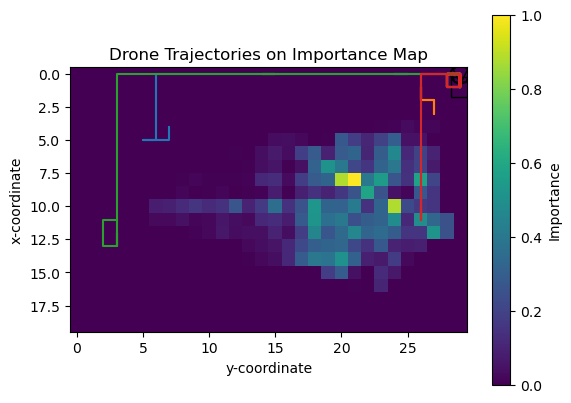

[5.133388941669321, 5.133388941669321, -5.133388441669322, 5.133388941669321]
Time | ep_step:  111 1
[-5.133388441669323, -5.133388441669323, 5.133388941669322, -5.133388441669323]
Time | ep_step:  112 2
[5.133388941669321, 5.133388941669321, -5.133388441669322, 5.133388941669321]
Time | ep_step:  113 3
[-5.133388441669323, -5.133388441669323, 5.133388941669322, -5.133388441669323]
Time | ep_step:  114 4
[5.133388941669321, 5.133388941669321, -5.133388441669322, 5.133388941669321]
-----------
Episode:  23
Time | ep_step:  115 0
[-5.133388441669323, -5.133388441669323, 5.133388941669322, -5.133388441669323]
Time | ep_step:  116 1
[5.133388941669321, 5.133388941669321, -5.133388441669322, 5.133388941669321]
Time | ep_step:  117 2
[-5.133388441669323, -5.133388441669323, 5.133388941669322, -5.133388441669323]
Time | ep_step:  118 3
[5.133388941669321, 5.133388941669321, -5.133388441669322, 5.133388941669321]
Time | ep_step:  119 4
[7.741108407204632, -0.18338819166932385, 4.99999998737621

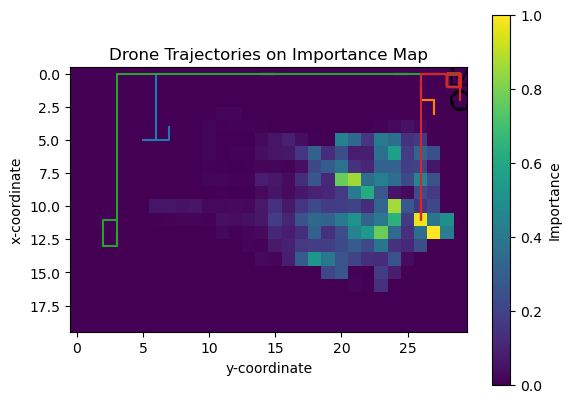

[-7.491117307179611, 0.30837929169434614, 0.30837929169434614, -7.491117307179611]
Time | ep_step:  121 1
[-0.4333787916443472, -0.4333787916443472, -0.4333787916443472, -0.4333787916443472]
Time | ep_step:  122 2
[0.5583797916693474, 0.5583797916693474, 0.5583797916693474, 0.5583797916693474]
Time | ep_step:  123 3
[-0.6833792916693437, -0.6833792916693437, -0.6833792916693437, -0.6833792916693437]
Time | ep_step:  124 4
[0.8083802916693443, 0.8083802916693443, 0.8083802916693443, 0.8083802916693443]
-----------
Episode:  25
Time | ep_step:  125 0
[-0.9333797916693451, -0.9333797916693451, -0.9333797916693451, -0.9333797916693451]
Time | ep_step:  126 1
[1.0583807916693422, 1.0583807916693422, 1.0583807916693422, 1.0583807916693422]
Time | ep_step:  127 2
[-1.1833802916693434, -1.1833802916693434, -1.1833802916693434, -1.1833802916693434]
Time | ep_step:  128 3
[1.308381291669341, 1.308381291669341, 1.308381291669341, 1.308381291669341]
Time | ep_step:  129 4
[-1.4333807916693426, -1.

In [6]:
# Set mode: random, greedy, lstm, nn
mode = 'gru'

pretrained_folder = r'\GRU_13_3_10000iter REAL pred_vdist.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)

In [10]:
reward_lstm = np.load(r'Results\11_20_2024_02_07_05\reward_memory.npy')
reward_gru = np.load(r'Results\06_05_2025_14_01_33\reward_memory.npy')

In [9]:
perc_visited_gru = np.load(r'Results\06_05_2025_14_01_33\list_of_perc_visited.npy')

In [10]:
perc_visited_gru.shape

(130,)

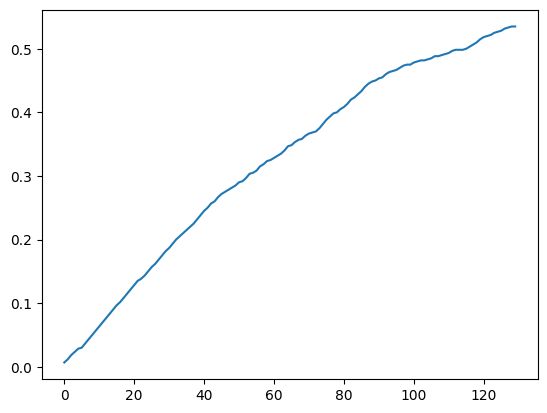

In [11]:
plt.plot(perc_visited_gru)

In [13]:
reward_lstm.shape

(6000,)

In [14]:
reward_gru.shape

(6000,)

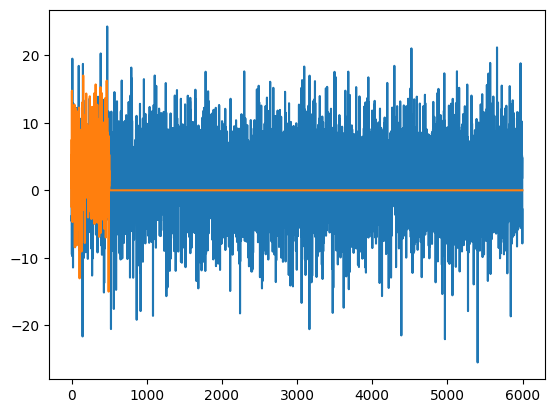

In [12]:
plt.plot(reward_lstm)
plt.plot(reward_gru)